# Self Organizing Maps

Self Organizing Map (SOM) proposed by Teuvo Kohonen is a data visualization technique. It helps to **understand high dimensional data by reducing the dimensions of data to a map**. And also it **showcases clustering by grouping similar data together**. This clustering ability was well received to after a variant of SOM, Growing Self Organizing ma was introduced.

Self-organizing maps (SOM) are a class of **unsupervised learning neural networks used for feature detection**. SOM are used to **project a high dimensional data into a smaller set and are used for dimensionality reduction**.

SOMs differ from conventional artificial neural networks as they apply competitive learning when compared to error correlated learning, which involves backpropagation and gradient descent. In SOM, the training data has no labels and the map learns to differentiate and distinguish features based on similarities.

# SOM Algorithm

- Step 1 : Initialize weights $w_{ij}$
- Step 2 : Calculate distance $d_{ij} = \sum (w_{ij} - x_i)^2$
- Step 3 : Calcualte $w_{ij}(t+1) = w_{ij}(t) + \theta(t) \times \alpha(t)\times \bigg( x_i(t) - w_{ij}(t) \bigg)$

, where $x_i(t)$ is the characteristics of the samples, $\alpha(t)$ is a learning rate and $\theta(t)$ is the neighbourhood function.

The weights are adjusted iteratively from the Euclidean distance by updating the learning rate. The neuron whose weight vector is most similar to the input is called the best matching unit (BMU). Once the BMU has been determined, we then calculate which of the other nodes are within the BMU’s neighborhood. Nodes found within the radius are deemed to be inside the neighborhood of the BMU. This process is repeated until convergence or number of iterations.

# Implementation

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import random

# SOM & Sklearn library
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler

# Visualization library
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# set seed
random.seed(2022)
np.random.seed(2022)

## Load Data

In [3]:
# Read cluster file saved locally
df = pd.read_csv('cluster_new.csv', index_col=0)
df

,Cluster,Companies Name,Companies,ATR,CHG
0,0,Microsoft,MSFT,1.252247,0.004346
1,0,Visa,V,1.474574,0.004592
2,1,Salesforce,CRM,2.197149,0.005698
3,2,Nvidia,NVDA,0.080804,0.007740
4,3,Goldman Sachs,GS,3.276638,0.001295
5,4,Boeing,BA,3.793542,0.003798
6,5,Amazon,AMZN,0.983712,0.006506
7,5,Procter & Gamble,PG,0.925470,0.002302
8,5,Nike,NKE,0.941665,0.004472
9,5,Merck,MRK,0.725919,0.002408


## Define Fearture Matrix

In [4]:
# Define feature matrix
X = df[['ATR', 'CHG']]

# Transform the feature matrix
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X

array([[0.31552011, 0.5029675 ],
       [0.37540218, 0.53899155],
       [0.57002272, 0.70098275],
       [0.        , 1.        ],
       [0.86077541, 0.05628835],
       [1.        , 0.42270554],
       [0.24319203, 0.81933265],
       [0.22750483, 0.20364443],
       [0.23186685, 0.52142565],
       [0.17375736, 0.21919511],
       [0.4939577 , 0.29607757],
       [0.60409507, 0.38756171],
       [0.67622878, 0.58470021],
       [0.34136068, 0.24006148],
       [0.32928683, 0.20473495],
       [0.38301915, 0.32276125],
       [0.29131047, 0.20191753],
       [0.37819043, 0.37667988],
       [0.37387988, 0.33654873],
       [0.29447207, 0.23572859],
       [0.42259731, 0.        ],
       [0.0958494 , 0.14995345],
       [0.10681613, 0.14876124],
       [0.15786725, 0.72822554],
       [0.10403642, 0.2164799 ],
       [0.07310302, 0.22764399],
       [0.46195781, 0.60176131],
       [0.43272291, 0.61798195],
       [0.34105373, 0.03585188]])

## Train SOM

In [5]:
MiniSom?

Init signature:
MiniSom(
    x,
    y,
    input_len,
    sigma=1,
    learning_rate=0.5,
    decay_function='asymptotic_decay',
    neighborhood_function='gaussian',
    topology='rectangular',
    activation_distance='euclidean',
    random_seed=None,
    sigma_decay_function='asymptotic_decay',
)
Docstring:      <no docstring>
Init docstring:
Initializes a Self Organizing Maps.

A rule of thumb to set the size of the grid for a dimensionality
reduction task is that it should contain 5*sqrt(N) neurons
where N is the number of samples in the dataset to analyze.

E.g. if your dataset has 150 samples, 5*sqrt(150) = 61.23
hence a map 8-by-8 should perform well.

Parameters
----------
x : int
    x dimension of the SOM.

y : int
    y dimension of the SOM.

input_len : int
    Number of the elements of the vectors in input.

sigma : float, optional (default=1)
    Spread of the neighborhood function.

    Needs to be adequate to the dimensions of the map
    and the neighborhood function.

In [6]:
x_dim = y_dim = int(5 * np.sqrt(X.shape[0]))

# Initialize a 15x15 SOM - Thumb rule is 5 * sqrt(n) > 5x5 SOM
som = MiniSom(x_dim, y_dim, 2, learning_rate=0.5, sigma=5, random_seed=42)

# Initialize with randon weights
som.random_weights_init(X)

# Trains SOM with 10000 iterations
som.train_batch(X, 10000, verbose=True)

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.0014723235429671456


 [  4006 / 10000 ]  40% - 0:00:01 left 

 [  5049 / 10000 ]  50% - 0:00:00 left 

 [  6025 / 10000 ]  60% - 0:00:00 left 

 [  6997 / 10000 ]  70% - 0:00:00 left 

 [  8017 / 10000 ]  80% - 0:00:00 left 

 [  8948 / 10000 ]  89% - 0:00:00 left 

 [  9968 / 10000 ] 100% - 0:00:00 left 

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.0014909778021713492


In [7]:
som.win_map

<bound method MiniSom.win_map of <minisom.MiniSom object at 0x000001AA26881070>>

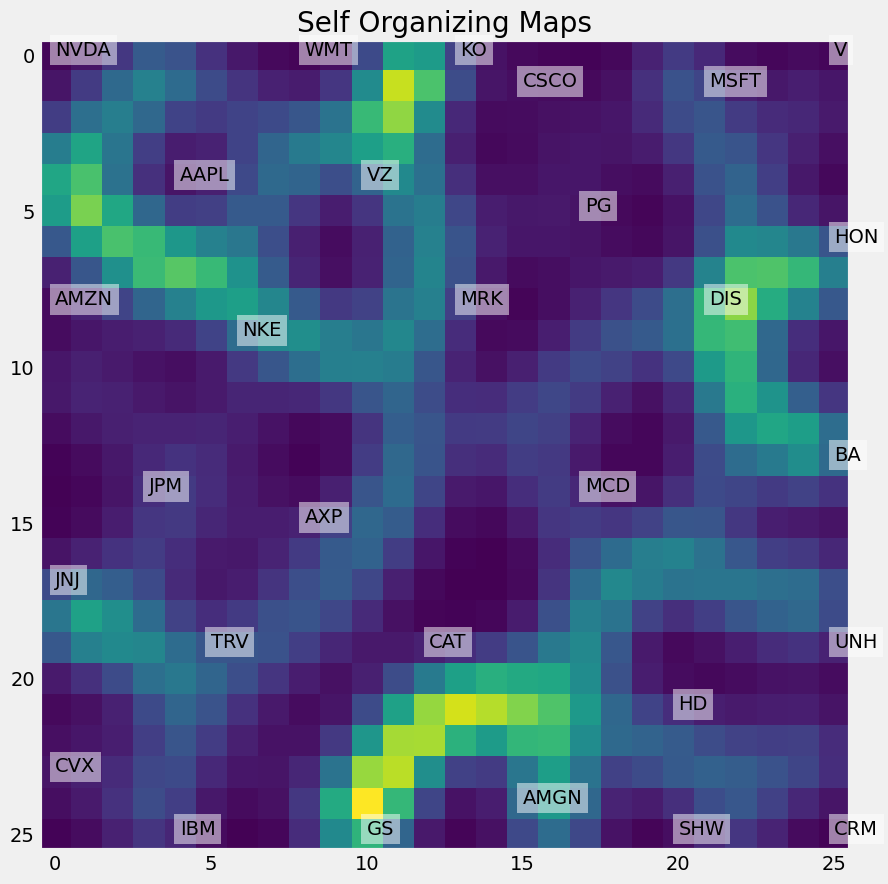

In [8]:
# Plot SOM
plt.figure(figsize=(20, 10))
for ix in range(len(X)):
    winner = som.winner(X[ix])
    plt.text(winner[0], winner[1], df.Companies[ix], bbox=dict(facecolor='white', alpha=0.5, lw=0)) 
plt.imshow(som.distance_map())
plt.grid(False)
plt.title('Self Organizing Maps');

*Result of training the SOM with feature set X and labelling it at their respective SOM neurons.*

In [9]:
# List the corresponding companies
for ix in range(len(X)):
    winner = som.winner(X[ix])
    print(winner[0], winner[1], df['Companies Name'][ix])

21 1 Microsoft
25 0 Visa
25 25 Salesforce
0 0 Nvidia
10 25 Goldman Sachs
25 13 Boeing
0 8 Amazon
17 5 Procter & Gamble
6 9 Nike
13 8 Merck
12 19 Caterpillar
15 24 Amgen
25 19 UnitedHealth Group
8 15 American Express
5 19 Travelers
17 14 McDonald's
0 17 Johnson & Johnson
25 6 Honeywell
21 8 Disney
3 14 JPMorgan Chase
4 25 IBM
13 0 Coca-Cola
15 1 Cisco
4 4 Apple
10 4 Verizon
8 0 Walmart
20 21 Home Depot
20 25 Sherwin-Williams
0 23 Chevron


# References

MiniSom